# A new measure of $\beta$-diversity with spatial community
Longxiao, LMU
python version: 3.10.19

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy.integrate import trapezoid
from scipy.stats import (
    ttest_rel,
    levene
)

In [39]:
with open("record_mult_diffu.pkl", "rb") as f:
    record_mult_d = pickle.load(f)

## Measure $\beta$-diversity in a continuous distribution

With continuous distribution data of species, we could extend biodiversity measures based on informational entropy to a continuous measure.
$$
\alpha(x) = -\sum_i p_i(x) \ln\big(p_i(x)\big),  \qquad p_i(x) = \frac{N_i(x)}{\sum_{j} N_j(x)}
$$

In [40]:
N = np.array(record_mult_d[-1])   # shape = (n_species, n_x)

# ----------------------------
#  p_i = N_i / sum_i N_i
# ----------------------------

sum_N = np.sum(N, axis=0)
sum_N_safe = np.where(sum_N == 0, 1, sum_N)

p = N / sum_N_safe

# ----------------------------
# S(x) = -sum_i p_i ln p_i
# ----------------------------

p_safe = np.where(p > 0, p, 1)

entropy_x = -np.sum(p * np.log(p_safe), axis=0)

# entropy_x, alpha biodiversity
#print(entropy_x)
x = np.linspace(-1, 1, 1000)

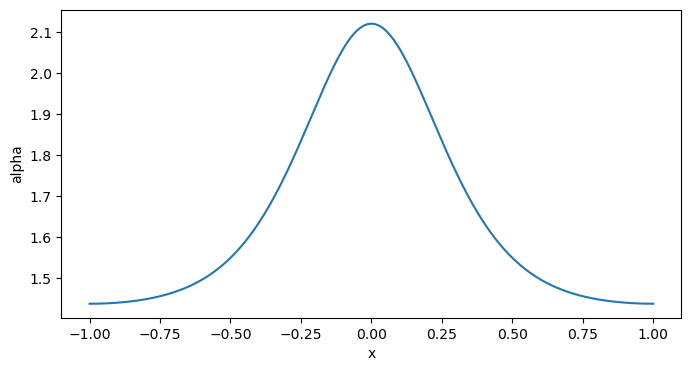

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(x, entropy_x)
plt.xlabel('x')
plt.ylabel('alpha')
plt.show()

Also, for $\gamma$ diversity
$$
\gamma = -\sum_i q_i \ln(q_i), \qquad q_i = \frac{\int N_i(x)\,\mathrm{d}x}{\sum_{j} \int N_j(x)\,\mathrm{d}x}
$$

In [42]:
# \int N_i(x) dx
integrals = np.trapz(N, x=x, axis=1)

print(integrals)

sum_IN = np.sum(integrals, axis=0) 

ip = integrals / sum_IN

gamma_div = -np.sum(ip * np.log(ip), axis=0)

print(gamma_div)

[0.45151143 0.23351044 0.12198073 0.0643101  0.03419609 0.01832864
 0.0098974  0.00538216 0.45151143 0.23351044 0.12198073 0.0643101
 0.03419609 0.01832864 0.0098974  0.00538216]
2.1150344737380635


Then $beta$ diversity is defined as the fraction of average $\alpha$ and $\gamma$,
$$\beta = \frac{\gamma}{\frac{1}{L} \int \alpha(x)\,\mathrm{d}x}$$

In [43]:
alpha_div_avg = np.trapz(entropy_x, x=x)
print(alpha_div_avg/2)

1.653997024759006


In [44]:
beta_div = 2*gamma_div/alpha_div_avg
print(beta_div)

1.2787414016335565


And here we got the "true value" of $\beta$

## Sample from the continuous distribution

Now we want to compare two methods of measuring $\beta$ diversity, if we have data from some discrete sampling spots:
- directly calculate $\beta$ based on the discrete data
- first fit these data to certain distribution (for example, logistic), then calculate $beta$ based on the continuous.

To do so, we first generate some samples from the simulated distribution.

In [45]:
import numpy as np

def sample_from_final_state(
    records,
    x,
    n_points,
    k,
    mode="uniform",
    replace=False,
    seed=None
):
    """
    sample from the distribution

    Returns
    -------
    samples : list of dict
        sample:
        {
            "index"
            "x"
            "counts": for all species
        }
    """

    rng = np.random.default_rng(seed)

    final_state = records[-1]

    n_species, nx = final_state.shape

    # randomly choose sample positions

    if mode == "uniform":
        indices = np.linspace(0, nx - 1, n_points, dtype=int)

    elif mode == "random":
        indices = rng.choice(nx, size=n_points, replace=replace)

    else:
        raise ValueError("mode must be 'uniform' or 'random'")

    # sample in each spots

    samples = []

    for idx in indices:

        abund = final_state[:, idx]

        total = abund.sum()

        if total <= 0:
            probs = np.ones(n_species) / n_species
        else:
            probs = abund / total

        # the distribution follows multinomial distribution
        counts = rng.multinomial(k, probs)

        samples.append({
            "index": int(idx),
            "x": float(x[idx]),
            "counts": counts
        })

    return samples

In [46]:
samples = sample_from_final_state(
    record_mult_d,
    x,
    n_points=10,
    k=100,
    mode="uniform",
    seed=1
)

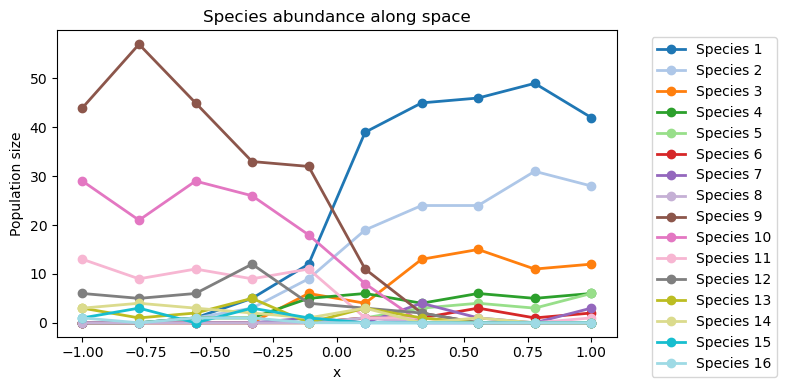

In [47]:
# sort samples by x

samples_sorted = sorted(
    samples,
    key=lambda s: s["x"]
)

positions = np.array([
    s["x"] for s in samples_sorted
])

community_matrix = np.array([
    s["counts"] for s in samples_sorted
])

# shape = (n_points, n_species)

n_points, n_species = community_matrix.shape

colors = plt.cm.tab20(
    np.linspace(0, 1, n_species)
)

plt.figure(figsize=(8, 4))

for i in range(n_species):

    plt.plot(
        positions,
        community_matrix[:, i],
        marker='o',
        linewidth=2,
        color=colors[i],
        label=f"Species {i+1}"
    )

plt.xlabel("x")

plt.ylabel("Population size")

plt.title("Species abundance along space")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    ncol=1
)

plt.tight_layout()

plt.show()

Then we could calculate $beta$ on this kind of sample, for example,

In [48]:
def shannon_index(counts):
    """
    counts : 1D abundance array
    """

    counts = np.asarray(counts, dtype=float)

    total = counts.sum()

    if total <= 0:
        return 0.0

    p = counts / total

    p = p[p > 0]

    return -np.sum(p * np.log(p))

In [49]:
def beta_diversity_discrete(samples):
    
    community_matrix = np.array([
        s["counts"] for s in samples
    ])

    # =========================
    # alpha
    # =========================

    alpha_values = np.array([
        shannon_index(row)
        for row in community_matrix
    ])

    alpha_mean = alpha_values.mean()

    # =========================
    # gamma
    # =========================

    pooled = community_matrix.sum(axis=0)

    gamma = shannon_index(pooled)

    # =========================
    # beta
    # =========================

    beta = gamma / alpha_mean

    return {
        "alpha_values": alpha_values,
        "alpha_mean": alpha_mean,
        "gamma": gamma,
        "beta": beta
    }

In [50]:
def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

In [51]:
def fit_species_logistic(samples):

    positions = np.array([
        s["x"] for s in samples
    ])

    community_matrix = np.array([
        s["counts"] for s in samples
    ])

    n_species = community_matrix.shape[1]

    fitted_params = []

    for i in range(n_species):

        y = community_matrix[:, i]

        # initial guess
        p0 = [
            y.max(),
            1.0,
            0.0
        ]

        try:

            popt, _ = curve_fit(
                logistic,
                positions,
                y,
                p0=p0,
                maxfev=10000
            )

        except RuntimeError:

            popt = [0, 0, 0]

        fitted_params.append(popt)

    return np.array(fitted_params)

In [52]:
def beta_diversity_continuous(
    samples,
    x_grid=None,
    nx=1000
):
    """
    logistic连续空间 beta diversity
    """

    positions = np.array([
        s["x"] for s in samples
    ])

    community_matrix = np.array([
        s["counts"] for s in samples
    ])

    # =========================
    # regression logistic
    # =========================

    params = fit_species_logistic(samples)

    n_species = community_matrix.shape[1]

    # =========================
    # continuous space
    # =========================

    xmin = positions.min()
    xmax = positions.max()

    if x_grid is None:
        x_grid = np.linspace(xmin, xmax, nx)

    dx = x_grid[1] - x_grid[0]

    # =========================
    # abundance
    # =========================

    fitted = np.zeros((n_species, len(x_grid)))

    for i in range(n_species):

        L, k, x0 = params[i]

        fitted[i] = logistic(x_grid, L, k, x0)

        # 防止负值
        fitted[i] = np.clip(fitted[i], 0, None)

    # =========================
    # alpha(x)
    # =========================

    alpha_x = np.zeros(len(x_grid))

    for j in range(len(x_grid)):

        local = fitted[:, j]

        alpha_x[j] = shannon_index(local)

    # average alpha
    alpha_mean = trapezoid(alpha_x, x_grid) / (xmax - xmin)

    # =========================
    # gamma
    # =========================

    species_integrals = np.array([
        trapezoid(fitted[i], x_grid)
        for i in range(n_species)
    ])

    gamma = shannon_index(species_integrals)

    # =========================
    # beta
    # =========================

    beta = gamma / alpha_mean

    return {
        "x_grid": x_grid,
        "fitted": fitted,
        "alpha_x": alpha_x,
        "alpha_mean": alpha_mean,
        "gamma": gamma,
        "beta": beta,
        "params": params
    }

In [53]:
res1 = beta_diversity_discrete(samples)

print(res1["beta"])

1.3410777628190136


In [54]:
res2 = beta_diversity_continuous(samples)

print(res2["beta"])

1.2966786585054937


Then, we compare this two measures. We generate 20 samples, each sample 10 spots, and 100 individual in each spots. Then we calculate both measure on these samples, and compare to the true value. 

In [55]:
import numpy as np

def generate_beta_statistics(
    records,
    x,
    n_replicates=20,
    n_points=10,
    k=100,
    base_seed=None
):

    discrete_betas = []
    continuous_betas = []

    all_samples = []

    rng = np.random.default_rng(base_seed)

    for rep in range(n_replicates):

        # different seed
        seed = rng.integers(0, 10**9)

        # random sample
        samples = sample_from_final_state(
            records=records,
            x=x,
            n_points=n_points,
            k=k,
            mode="random",
            replace=False,
            seed=seed
        )

        all_samples.append(samples)

        # discrete measure

        res_discrete = beta_diversity_discrete(samples)

        discrete_betas.append(
            res_discrete["beta"]
        )

        # continuous measure

        res_continuous = beta_diversity_continuous(samples)

        continuous_betas.append(
            res_continuous["beta"]
        )

    return {
        "discrete_betas": np.array(discrete_betas),
        "continuous_betas": np.array(continuous_betas),
        "samples": all_samples
    }

In [56]:
beta_results = generate_beta_statistics(
    records=record_mult_d,
    x=x,
    n_replicates=50,
    n_points=10,
    k=100,
    base_seed=123
)

C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1070614113.py:2: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1531749656.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


In [57]:
discrete_betas = beta_results["discrete_betas"]

continuous_betas = beta_results["continuous_betas"]

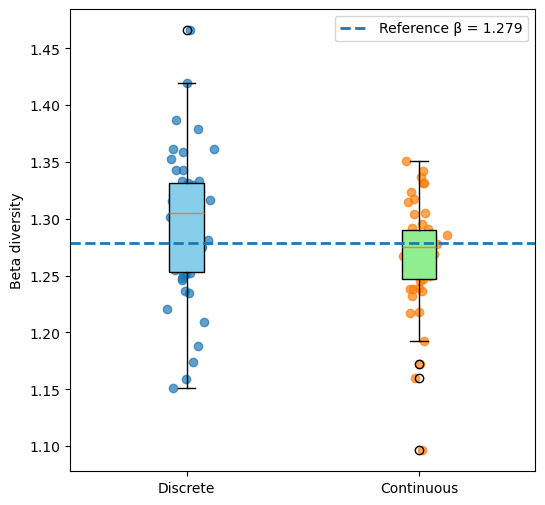

In [58]:
plt.figure(figsize=(6,6))

box = plt.boxplot(
    [discrete_betas, continuous_betas],
    patch_artist=True,
    tick_labels=["Discrete", "Continuous"]
)

colors = ["skyblue", "lightgreen"]

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

for i, data in enumerate(
    [discrete_betas, continuous_betas],
    start=1
):

    x_jitter = np.random.normal(
        i,
        0.04,
        size=len(data)
    )

    plt.scatter(
        x_jitter,
        data,
        alpha=0.7
    )

# true value

plt.axhline(
    beta_div,
    linestyle="--",
    linewidth=2,
    label=f"Reference β = {beta_div:.3f}"
)

plt.ylabel("Beta diversity")

#plt.title("Beta diversity distributions")

plt.legend()

plt.show()

Then, with different sample size,

C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1531749656.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1070614113.py:2: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))
c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\scipy\optimize\_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1531749656.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1070614113.py:2: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1531749656.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\10706

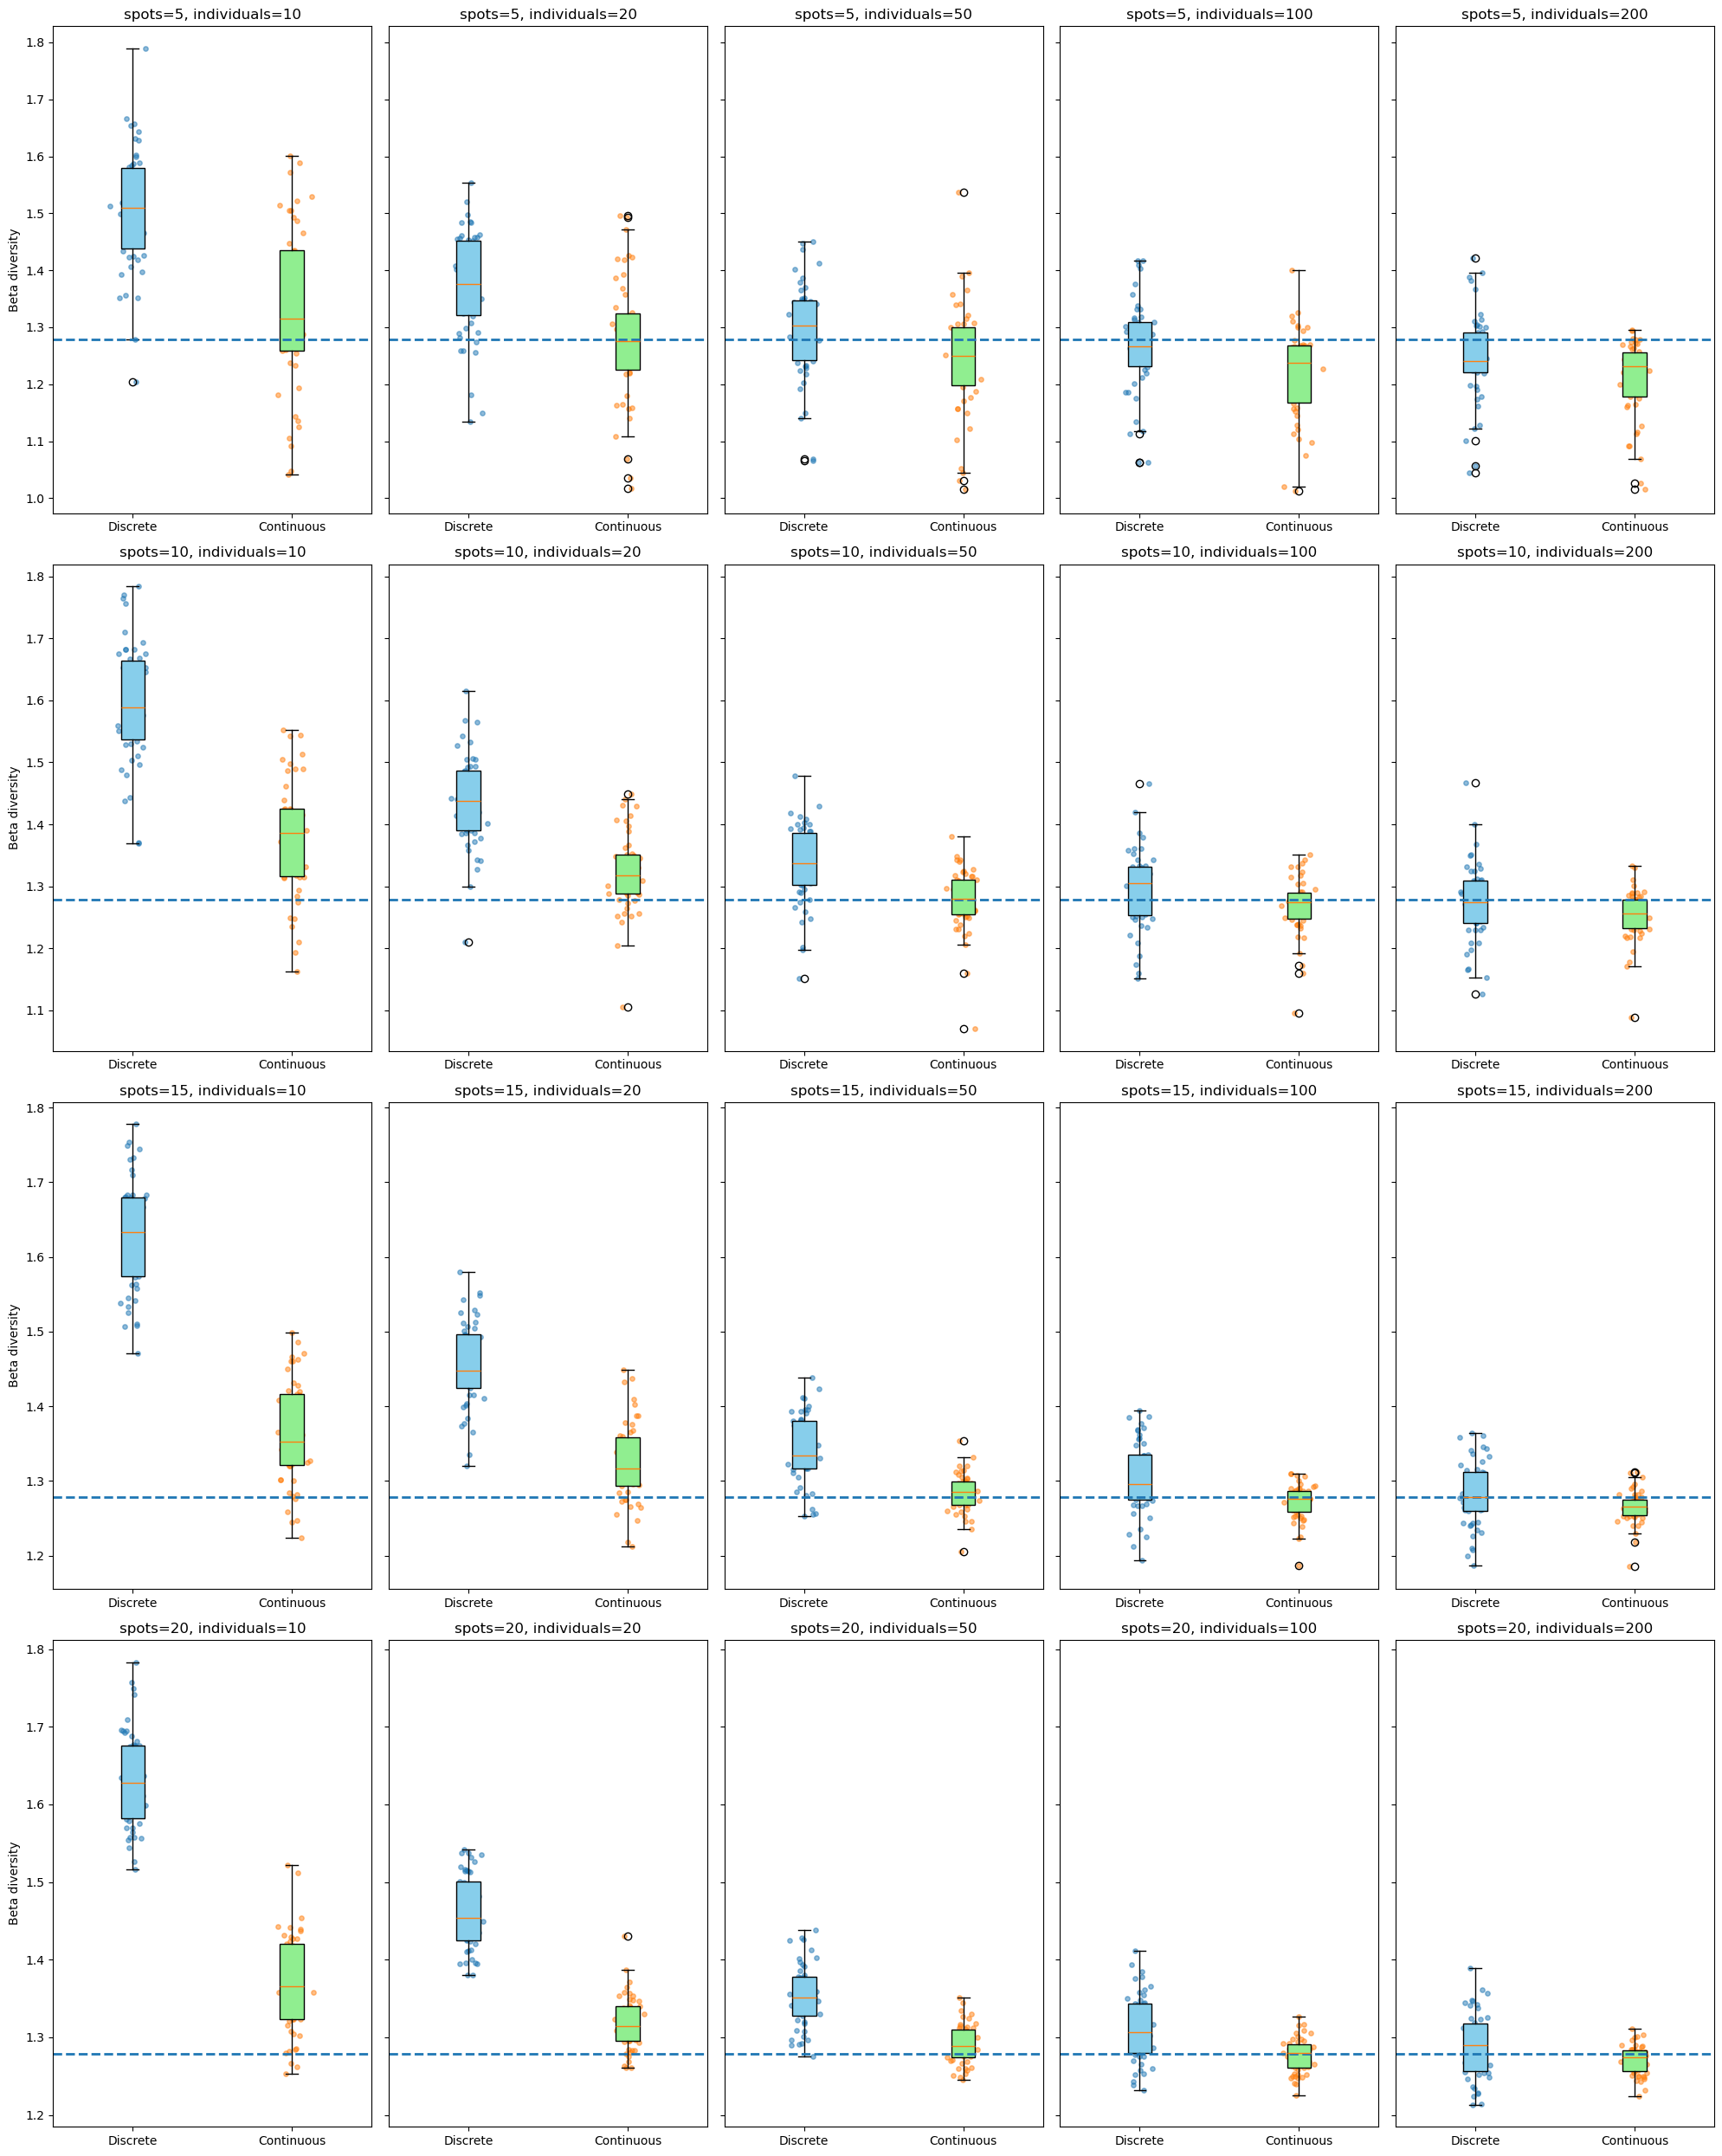

In [60]:
n_points_list = [5, 10, 15, 20]

k_list = [10, 20, 50, 100, 200]

fig, axes = plt.subplots(
    4,
    5,
    figsize=(20, 25),
    sharey='row'
)

for row, n_points in enumerate(n_points_list):

    for col, k in enumerate(k_list):

        ax = axes[row, col]

        # beta

        beta_results = generate_beta_statistics(
            records=record_mult_d,
            x=x,
            n_replicates=50,
            n_points=n_points,
            k=k,
            base_seed=123
        )

        discrete_betas = beta_results["discrete_betas"]

        continuous_betas = beta_results["continuous_betas"]

        # draw

        box = ax.boxplot(
            [discrete_betas, continuous_betas],
            patch_artist=True,
            tick_labels=["Discrete", "Continuous"]
        )
        colors = ["skyblue", "lightgreen"]
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)

        for i, data in enumerate(
            [discrete_betas, continuous_betas],
            start=1
        ):

            x_jitter = np.random.normal(
                i,
                0.04,
                size=len(data)
            )

            ax.scatter(
                x_jitter,
                data,
                alpha=0.5,
                s=15
            )

        ax.axhline(
            beta_div,
            linestyle="--",
            linewidth=2
        )

        ax.set_title(
            f"spots={n_points}, individuals={k}"
        )

        if col == 0:
            ax.set_ylabel("Beta diversity")
        else:
            ax.set_ylabel("")


plt.tight_layout()

plt.show()

Statistic test between two methods

In [61]:
def compare_beta_estimators(
    discrete_betas,
    continuous_betas,
    beta_true
):

    mean_discrete = np.mean(discrete_betas)
    mean_continuous = np.mean(continuous_betas)

    var_discrete = np.var(
        discrete_betas,
        ddof=1
    )

    var_continuous = np.var(
        continuous_betas,
        ddof=1
    )

    bias_discrete = mean_discrete - beta_true
    bias_continuous = mean_continuous - beta_true

    mse_discrete = np.mean(
        (discrete_betas - beta_true)**2
    )

    mse_continuous = np.mean(
        (continuous_betas - beta_true)**2
    )

    t_stat, t_p = ttest_rel(
        discrete_betas,
        continuous_betas
    )

    lev_stat, lev_p = levene(
        discrete_betas,
        continuous_betas
    )

    return {

        "mean_discrete": mean_discrete,
        "mean_continuous": mean_continuous,

        "var_discrete": var_discrete,
        "var_continuous": var_continuous,

        "bias_discrete": bias_discrete,
        "bias_continuous": bias_continuous,

        "mse_discrete": mse_discrete,
        "mse_continuous": mse_continuous,

        "t_test_pvalue": t_p,

        "levene_pvalue": lev_p
    }

C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1531749656.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1070614113.py:2: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\67302001.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1531749656.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\1070614113.py:2: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))
C:\Users\muliy\AppData\Local\Temp\ipykernel_18904\67302001.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of

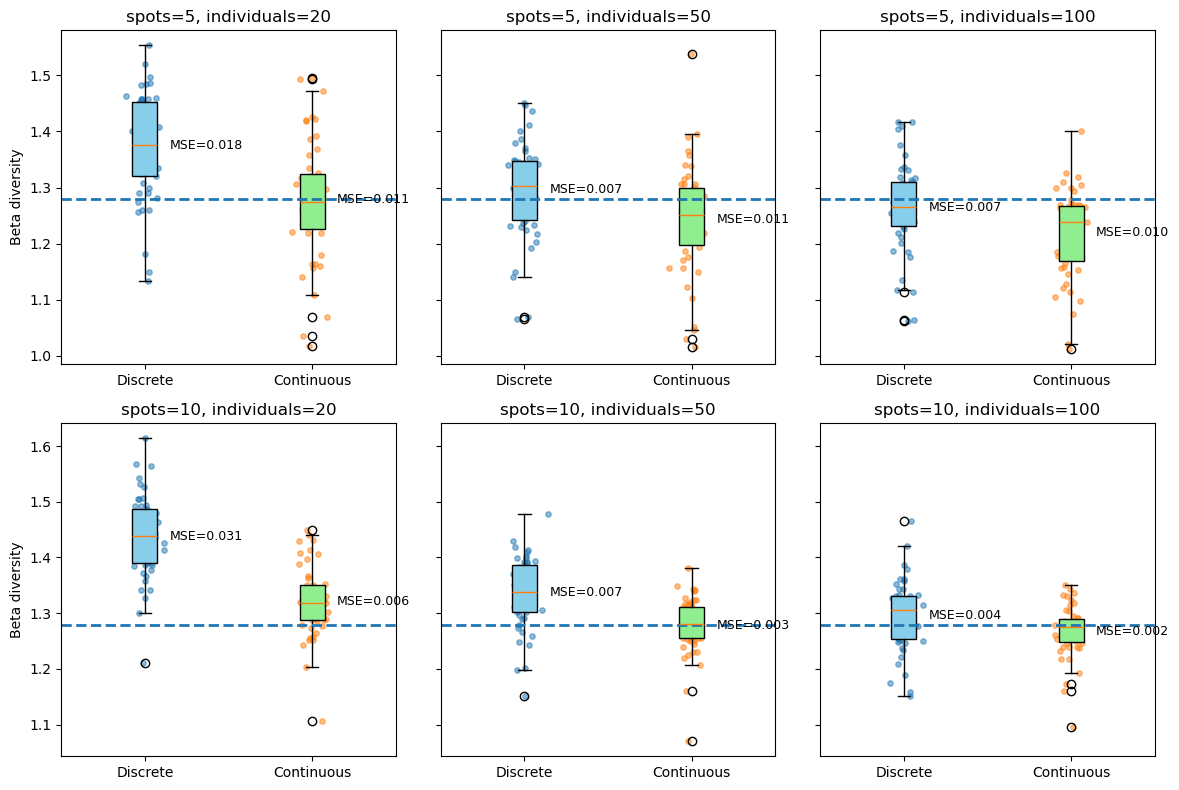

In [62]:
n_points_list = [5, 10]

k_list = [20, 50, 100]

all_statistics = {}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
    sharey='row'
)

for row, n_points in enumerate(n_points_list):

    for col, k in enumerate(k_list):

        ax = axes[row, col]

        beta_results = generate_beta_statistics(
            records=record_mult_d,
            x=x,
            n_replicates=50,
            n_points=n_points,
            k=k,
            base_seed=123
        )

        discrete_betas = beta_results["discrete_betas"]

        continuous_betas = beta_results["continuous_betas"]

        stats_result = compare_beta_estimators(
            discrete_betas,
            continuous_betas,
            beta_div
        )

        all_statistics[(n_points, k)] = stats_result

        box = ax.boxplot(
            [discrete_betas, continuous_betas],
            patch_artist=True,
            labels=["Discrete", "Continuous"]
        )

        # 颜色
        colors = ["skyblue", "lightgreen"]

        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)

        for i, data in enumerate(
            [discrete_betas, continuous_betas],
            start=1
        ):

            x_jitter = np.random.normal(
                i,
                0.04,
                size=len(data)
            )

            ax.scatter(
                x_jitter,
                data,
                alpha=0.5,
                s=15
            )

        ax.axhline(
            beta_div,
            linestyle="--",
            linewidth=2
        )

        mean_discrete = np.mean(discrete_betas)

        mean_continuous = np.mean(continuous_betas)

        ax.text(
            1.15,
            mean_discrete,
            f"MSE={stats_result['mse_discrete']:.3f}",
            va='center',
            fontsize=9
        )

        ax.text(
            2.15,
            mean_continuous,
            f"MSE={stats_result['mse_continuous']:.3f}",
            va='center',
            fontsize=9
        )

        ax.set_title(
            f"spots={n_points}, individuals={k}"
        )

        if col == 0:
            ax.set_ylabel("Beta diversity")
        else:
            ax.set_ylabel("")

plt.tight_layout()

plt.show()

In [63]:
stats_result = compare_beta_estimators(
    discrete_betas,
    continuous_betas,
    beta_div
)

In [64]:
print(stats_result)

{'mean_discrete': 1.2961787619783685, 'mean_continuous': 1.2672814925100886, 'var_discrete': 0.003930218399546959, 'var_continuous': 0.002189710281613477, 'bias_discrete': 0.017437360344811914, 'bias_continuous': -0.011459909123467948, 'mse_discrete': 0.004155675567350846, 'mse_continuous': 0.002277245593099352, 't_test_pvalue': 3.855004388618297e-05, 'levene_pvalue': 0.04788923607394733}


In [65]:
rows = []

for (n_points, k), stats_result in all_statistics.items():

    rows.append({

        "n_points": n_points,
        "k": k,

        "MSE_discrete":
            stats_result["mse_discrete"],

        "MSE_continuous":
            stats_result["mse_continuous"],

        "t_test_pvalue":
            stats_result["t_test_pvalue"],

        "Levene_pvalue":
            stats_result["levene_pvalue"]
    })

stats_table = pd.DataFrame(rows)

stats_table = stats_table.sort_values(
    by=["n_points", "k"]
)

stats_table = stats_table.reset_index(drop=True)

print(stats_table)

   n_points    k  MSE_discrete  MSE_continuous  t_test_pvalue  Levene_pvalue
0         5   20      0.017768        0.011372   3.272508e-12       0.650918
1         5   50      0.007355        0.010655   8.447238e-07       0.698522
2         5  100      0.006504        0.009585   2.452864e-05       0.837288
3        10   20      0.030553        0.005693   6.976687e-16       0.289661
4        10   50      0.007412        0.002540   5.325697e-10       0.056237
5        10  100      0.004156        0.002277   3.855004e-05       0.047889
